In [20]:
pip install mlflow


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
import mlflow
import os

# Use the sqlite:/// prefix for a .db file
db_path = os.path.abspath("/Users/salmon/work/final_project/poc_project/uav-battery-prognostics/ml/notebooks/mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{db_path}")


In [22]:
pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
import platform
import sys
import os
import scipy.io
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

arch = platform.architecture()[0]
bit_size = importlib.import_module('struct').calcsize('P') * 8

print(f"--- System Check ---")
print(f"Python Version: {sys.version}")
print(f"Architecture:   {arch} ({bit_size}-bit)")
print(f"Executable:     {sys.executable}")

if bit_size == 32:
    raise RuntimeError("CRITICAL: You are running 32-bit Python.")

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except ImportError:
    print("Warning: XGBoost not found.")
    xgb = None

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    print("Warning: TensorFlow not found.")
    tf = None

try:
    import mlflow
    import mlflow.keras
    import mlflow.sklearn
except ImportError:
    print("Warning: MLflow not found.")
    mlflow = None

print("\n--- Dependency Check ---")
if tf:    print(f"TensorFlow: {tf.__version__}")
if xgb:   print(f"XGBoost:    {xgb.__version__}")
if mlflow: print(f"MLflow:     {mlflow.__version__}")
print("\nStatus: All systems ready." if all([tf, xgb, mlflow]) else "Status: MISSING LIBRARIES")

--- System Check ---
Python Version: 3.13.3 (main, Apr  8 2025, 13:54:08) [Clang 16.0.0 (clang-1600.0.26.6)]
Architecture:   64bit (64-bit)
Executable:     /Users/salmon/work/final_project/poc_project/venv/bin/python

--- Dependency Check ---
TensorFlow: 2.21.0
XGBoost:    3.2.0
MLflow:     3.12.0

Status: All systems ready.


## Dataset: NASA Battery Aging (B0005, B0006, B0007, B0018)
**Model type:** Multi-cycle summarized features + windowed BiLSTM  
**Use case:** Multiple consecutive discharge cycles available (history exists)

In [44]:
DATA_PATH    = '/Users/salmon/work/year3/2_semester/projectpreb/1. BatteryAgingARC-FY08Q4'   # <-- Change this
battery_list = [5, 6, 7, 18]


def preprocess_raw_data(battery_ids):
    summary_list = []
    for b_id in battery_ids:
        file_name = f'B00{b_id:02d}.mat'
        file_path = os.path.join(DATA_PATH, file_name)
        mat    = scipy.io.loadmat(file_path)
        key    = f'B00{b_id:02d}'
        data   = mat[key][0, 0]
        cycles = data['cycle'][0]

        for i in range(len(cycles)):
            if cycles[i]['type'][0] == 'discharge':
                c_data = cycles[i]['data'][0, 0]
                try:
                    capacity = float(c_data['Capacity'][0][0])
                except (KeyError, IndexError, TypeError):
                    continue
                time_vec = c_data['Time'][0]
                temp_vec = c_data['Temperature_measured'][0]
                volt_vec = c_data['Voltage_measured'][0]
                summary_list.append({
                    'battery_id': key,
                    'cycle'     : i + 1,
                    'capacity'  : capacity,
                    'duration'  : float(time_vec[-1] - time_vec[0]),
                    'avg_temp'  : float(np.mean(temp_vec)),
                    'v_drop'    : float(volt_vec[0] - volt_vec[-1]),
                })
    return pd.DataFrame(summary_list)


master_df = preprocess_raw_data(battery_list)
print(f"Total discharge cycles: {len(master_df)}")
print(f"Batteries: {master_df['battery_id'].unique().tolist()}")
master_df.head(10)

Total discharge cycles: 636
Batteries: ['B0005', 'B0006', 'B0007', 'B0018']


,battery_id,cycle,capacity,duration,avg_temp,v_drop
0,B0005,2,1.856487,3690.234,32.572328,0.914322
1,B0005,4,1.846327,3672.344,32.725235,0.889528
2,B0005,6,1.835349,3651.641,32.642862,0.860736
3,B0005,8,1.835263,3631.563,32.514876,0.874279
4,B0005,10,1.834646,3629.172,32.382349,0.882802
5,B0005,12,1.835662,3652.281,32.434182,0.886487
6,B0005,14,1.835146,3650.828,32.480416,0.894651
7,B0005,16,1.825757,3572.453,32.410462,0.872697
8,B0005,18,1.824774,3550.594,32.346141,0.891618
9,B0005,20,1.824613,3551.250,32.276798,0.900819


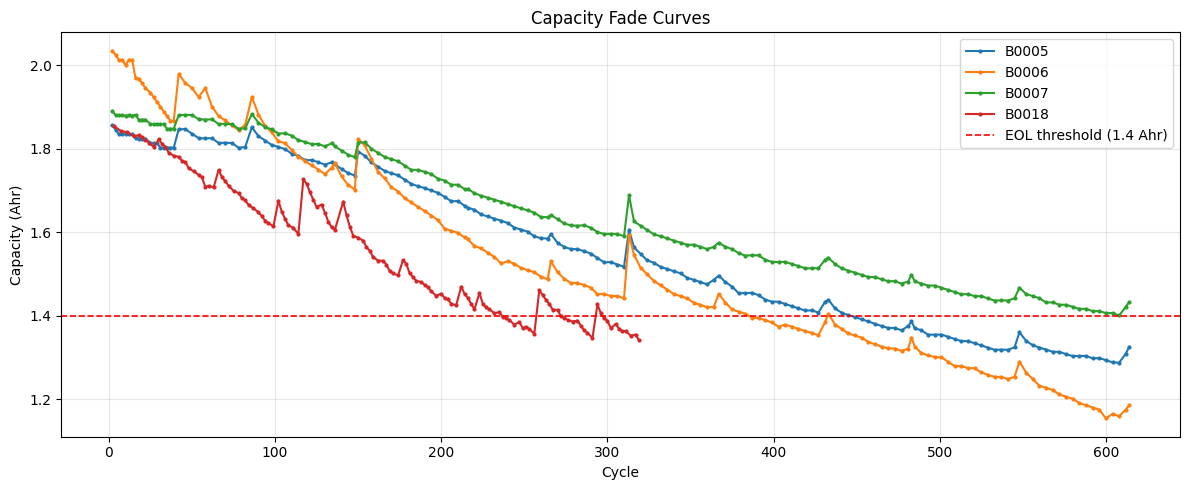

In [45]:
plt.figure(figsize=(12, 5))
for bid, grp in master_df.groupby('battery_id'):
    plt.plot(grp['cycle'], grp['capacity'], label=bid, marker='o', markersize=2)
plt.axhline(1.4, color='red', linestyle='--', linewidth=1.2, label='EOL threshold (1.4 Ahr)')
plt.title('Capacity Fade Curves')
plt.xlabel('Cycle'); plt.ylabel('Capacity (Ahr)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [46]:
from sklearn.preprocessing import MinMaxScaler

master_df = master_df.sort_values(['battery_id', 'cycle']).copy()

master_df['v_decay_rate'] = master_df['v_drop'] / master_df['duration']
master_df['temp_stability'] = (
    master_df.groupby('battery_id')['avg_temp']
    .transform(lambda x: x.rolling(window=3).std()).fillna(0)
)
master_df['cumulative_duration'] = (
    master_df.groupby('battery_id')['duration'].cumsum()
)
master_df['capacity_fade'] = (
    master_df.groupby('battery_id')['capacity'].diff().fillna(0)
)

features = [
    'cycle', 'duration', 'avg_temp', 'v_drop',
    'v_decay_rate', 'temp_stability', 'cumulative_duration'
]
target    = 'capacity'
train_ids = ['B0006', 'B0007', 'B0018']
test_id   = 'B0005'

train_df = master_df[master_df['battery_id'].isin(train_ids)].copy()
test_df  = master_df[master_df['battery_id'] == test_id].copy()

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[features])
y_train = scaler_y.fit_transform(train_df[[target]])
X_test        = scaler_X.transform(test_df[features])
y_test_actual = test_df[target].values

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Features: {features}")

Train shape: (468, 7), Test shape: (168, 7)
Features: ['cycle', 'duration', 'avg_temp', 'v_drop', 'v_decay_rate', 'temp_stability', 'cumulative_duration']


In [47]:
def create_sequences(data, target_data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:(i + window)])
        y.append(target_data[i + window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 15

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW_SIZE)
y_test_scaled = scaler_y.transform(test_df[[target]])
X_test_seq, y_test_seq = create_sequences(X_test, y_test_scaled, WINDOW_SIZE)
y_train_seq = y_train_seq.reshape(-1, 1)
y_test_seq  = y_test_seq.reshape(-1, 1)

print(f"LSTM Train X shape: {X_train_seq.shape}")
print(f"LSTM Test  X shape: {X_test_seq.shape}")

LSTM Train X shape: (453, 15, 7)
LSTM Test  X shape: (153, 15, 7)


In [48]:
mlflow.end_run()
mlflow.set_experiment("UAV_Battery_Health_Ensemble")
mlflow.start_run(run_name=f"{test_id}_multicycle_normal_load")

# ── Dataset & split ──────────────────────────────────────────────
mlflow.log_params({
    "dataset"          : "NASA_B0005_B0006_B0007_B0018",
    "test_battery"     : test_id,
    "train_batteries"  : str(train_ids),
    "window_size"      : WINDOW_SIZE,
    "features_count"   : len(features),
    "features_list"    : ", ".join(features),
})

# ── XGBoost config ───────────────────────────────────────────────
mlflow.log_params({
    "xgb_n_estimators"  : 300,
    "xgb_max_depth"     : 8,
    "xgb_learning_rate" : 0.05,
})

# ── LSTM config ──────────────────────────────────────────────────
mlflow.log_params({
    "lstm_layers"              : 3,
    "is_bidirectional"         : True,
    "layer1_units"             : 128,
    "layer2_units"             : 64,
    "layer3_units"             : 32,
    "dropout_rate"             : 0.2,
    "optimizer"                : "Adam",
    "lstm_learning_rate"       : 0.0001,
    "lstm_epochs_max"          : 1000,
    "lstm_early_stop_patience" : 15,
    "lstm_validation_split"    : 0.2,
})

# ── Tags ─────────────────────────────────────────────────────────
mlflow.set_tags({
    "model_type"  : "Hybrid_Ensemble",
    "data_source" : "NASA_B0005_B0006_B0007_B0018",
    "framework"   : "TensorFlow_Keras_XGBoost",
})

print("MLflow run started.")

2026/05/09 16:31:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 16:31:26 INFO mlflow.store.db.utils: Updating database tables


MLflow run started.


In [49]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds_scaled = lr_model.predict(X_test)
lr_preds = scaler_y.inverse_transform(lr_preds_scaled.reshape(-1, 1)).flatten()
mlflow.sklearn.log_model(lr_model, "baseline_lr")
print(f"Linear Regression complete. Sample: {lr_preds[:3]}")

2026/05/09 16:31:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:31:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression complete. Sample: [1.98432577 1.97059137 1.95698768]


In [50]:
xgb_model = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
xgb_preds_scaled = xgb_model.predict(X_test)
xgb_preds = scaler_y.inverse_transform(xgb_preds_scaled.reshape(-1, 1)).flatten()
mlflow.sklearn.log_model(xgb_model, "expert_xgboost")
print("XGBoost training complete.")

2026/05/09 16:31:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:31:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost training complete.


In [51]:
from tensorflow.keras.layers import Bidirectional

lstm_model = Sequential([
    Bidirectional(LSTM(128, activation='tanh', return_sequences=True),
                  input_shape=(WINDOW_SIZE, len(features))),
    Dropout(0.2),
    Bidirectional(LSTM(64, activation='relu', return_sequences=True)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse'
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
print("Starting Bidirectional LSTM training...")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=1000, validation_split=0.2,
    callbacks=[early_stop], verbose=1
)

lstm_raw_preds  = lstm_model.predict(X_test_seq)
lstm_final_part = scaler_y.inverse_transform(lstm_raw_preds).flatten()
full_lstm_preds = np.concatenate([xgb_preds[:WINDOW_SIZE], lstm_final_part])
offset = y_test_actual[0] - full_lstm_preds[0]
full_lstm_preds = full_lstm_preds + offset

mlflow.keras.log_model(lstm_model, "bidirectional_lstm_stacked")
print("LSTM training and calibration complete.")

Starting Bidirectional LSTM training...
Epoch 1/1000


/Users/salmon/work/final_project/poc_project/venv/lib/python3.13/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.2627 - val_loss: 0.0995
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1673 - val_loss: 0.0607
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0804 - val_loss: 0.0218
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0397 - val_loss: 0.0090
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0256 - val_loss: 0.0135
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0211 - val_loss: 0.0119
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0197 - val_loss: 0.0091
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0180 - val_loss: 0.0086
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0162 - val_loss: 0.0057
Epoch 10/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0151 - val_loss: 0.0060
Epoch 11/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0142 - val_loss: 0.0047
Epoch 12/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 

2026/05/09 16:31:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:31:51 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


LSTM training and calibration complete.


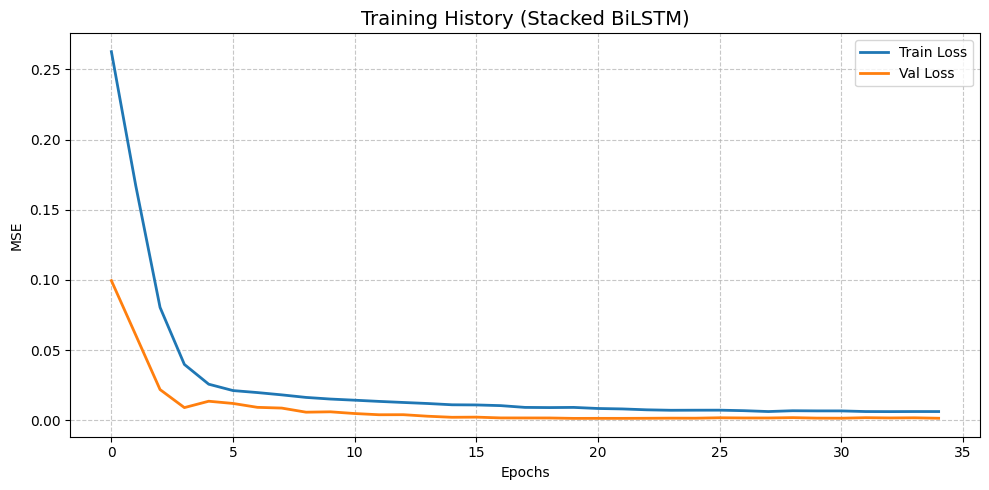

In [52]:
if 'history' in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'],     label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss',   color='#ff7f0e', linewidth=2)
    plt.title('Training History (Stacked BiLSTM)', fontsize=14)
    plt.xlabel('Epochs'); plt.ylabel('MSE')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

In [53]:
results = []
models  = {
    "Linear_Regression": lr_preds,
    "XGBoost"          : xgb_preds,
    "LSTM_Hybrid"      : full_lstm_preds
}
for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
    mae  = mean_absolute_error(y_test_actual, preds)
    r2   = r2_score(y_test_actual, preds)
    mlflow.log_metric(f"{name}_RMSE", rmse)
    mlflow.log_metric(f"{name}_R2",   r2)
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
mlflow.end_run()
print(pd.DataFrame(results))

               Model      RMSE       MAE        R2
0  Linear_Regression  0.040696  0.033626  0.954048
1            XGBoost  0.045879  0.038370  0.941598
2        LSTM_Hybrid  0.041354  0.034916  0.952551


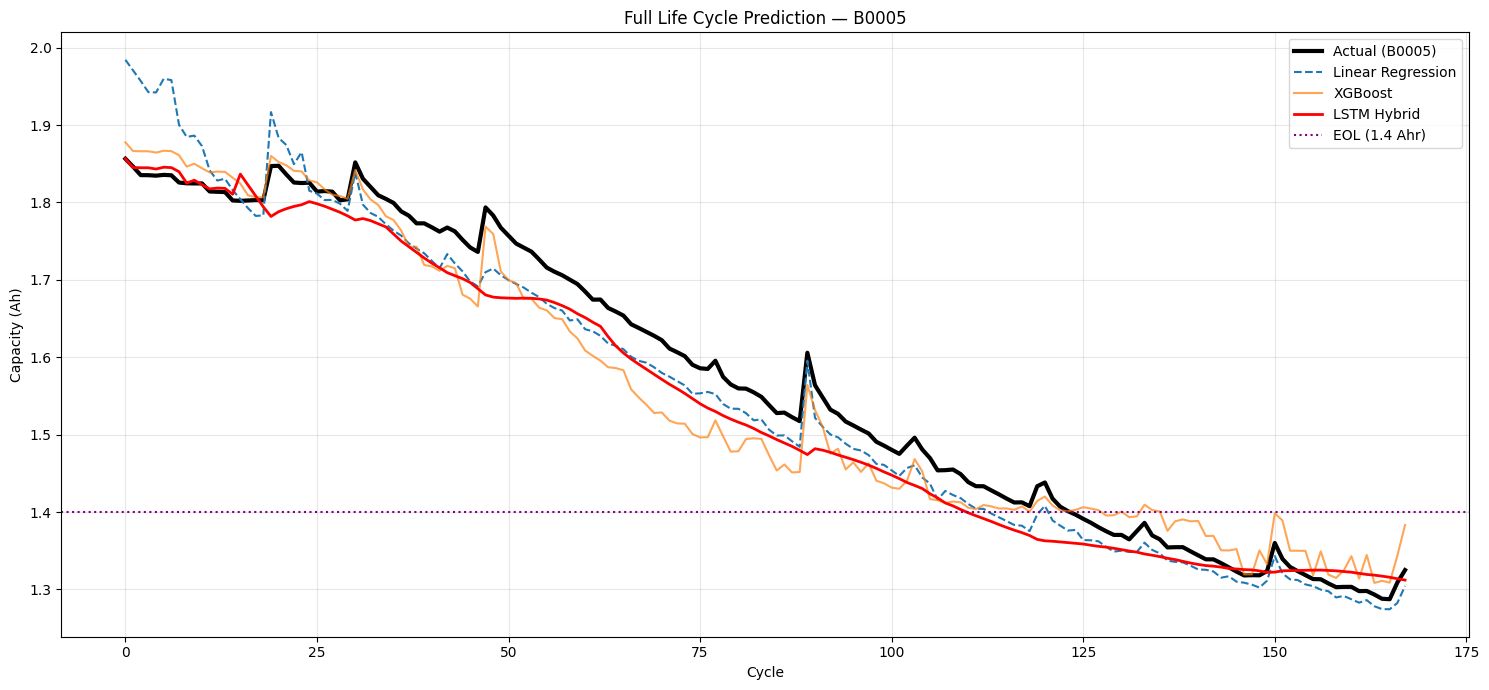

In [54]:
plt.figure(figsize=(15, 7))
plt.plot(y_test_actual,   label=f'Actual ({test_id})', color='black', linewidth=3)
plt.plot(lr_preds,        label='Linear Regression',   linestyle='--')
plt.plot(xgb_preds,       label='XGBoost',             alpha=0.7)
plt.plot(full_lstm_preds, label='LSTM Hybrid',          color='red', linewidth=2)
plt.axhline(1.4, color='purple', linestyle=':', linewidth=1.5, label='EOL (1.4 Ahr)')
plt.title(f"Full Life Cycle Prediction — {test_id}")
plt.xlabel("Cycle"); plt.ylabel("Capacity (Ah)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## Feature explain


In [55]:
pip install shap

  Using cached shap-0.51.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (5.0 kB)
Using cached shap-0.51.0-cp313-cp313-macosx_11_0_arm64.whl (561 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached llvmlite-0.47.0-cp313-cp313-macosx_12_0_arm64.whl (37.2 MB)
Using cached numba-0.65.1-cp313-cp313-macosx_12_0_arm64.whl (2.7 MB)

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


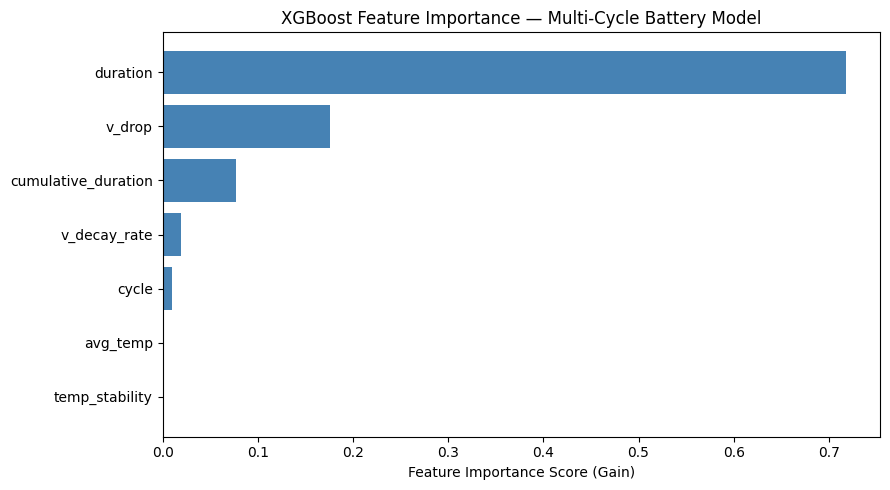


--- Domain Interpretation ---
  duration                  importance=0.7178  →  Discharge duration shrinks as capacity fades — battery empties faster.
  v_drop                    importance=0.1757  →  End-to-start voltage difference per cycle; widens as battery ages.
  cumulative_duration       importance=0.0775  →  Total discharge time accumulated reflects total energy delivered over the battery's life.
  v_decay_rate              importance=0.0189  →  Voltage drop rate captures how fast the battery loses voltage per second — faster = more worn.
  cycle                     importance=0.0094  →  Cycle count is a direct proxy for calendar age — higher cycle = more degraded.
  avg_temp                  importance=0.0005  →  Higher average temperature during discharge accelerates electrolyte degradation.
  temp_stability            importance=0.0002  →  Rolling temperature variance; instability may indicate uneven aging.


In [56]:
# ── B5: Feature Importance (XGBoost) ────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(9, 5))
bars = plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel("Feature Importance Score (Gain)")
plt.title("XGBoost Feature Importance — Multi-Cycle Battery Model")
plt.tight_layout()
plt.savefig("multicycle_feature_importance.png", dpi=150)
plt.show()

print("\n--- Domain Interpretation ---")
domain_hints = {
    'cycle'               : "Cycle count is a direct proxy for calendar age — higher cycle = more degraded.",
    'v_decay_rate'        : "Voltage drop rate captures how fast the battery loses voltage per second — faster = more worn.",
    'cumulative_duration' : "Total discharge time accumulated reflects total energy delivered over the battery's life.",
    'v_drop'              : "End-to-start voltage difference per cycle; widens as battery ages.",
    'duration'            : "Discharge duration shrinks as capacity fades — battery empties faster.",
    'avg_temp'            : "Higher average temperature during discharge accelerates electrolyte degradation.",
    'temp_stability'      : "Rolling temperature variance; instability may indicate uneven aging.",
}
for feat, imp in zip(sorted_features, sorted_importances):
    hint = domain_hints.get(feat, "")
    print(f"  {feat:<25s} importance={imp:.4f}  →  {hint}")

/var/folders/1z/7s93hcb139v8rrbcx9kyxvkm0000gn/T/ipykernel_11826/3063315979.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


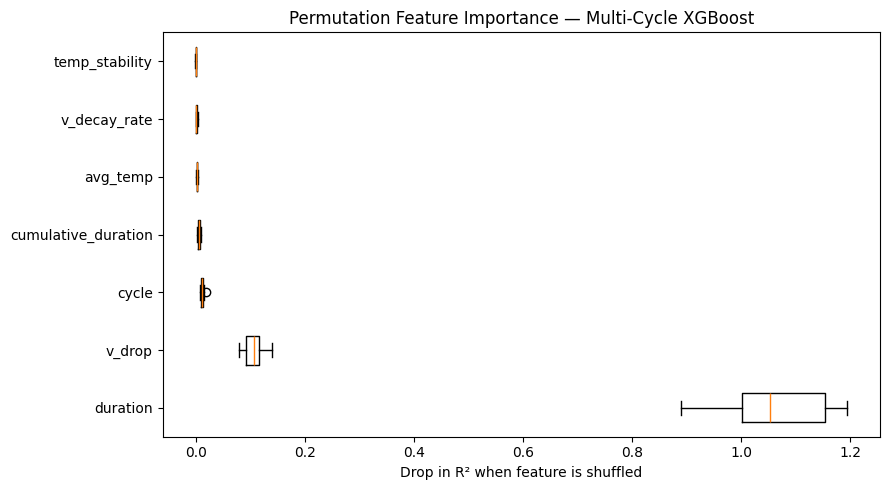

In [57]:
# ── B5: Permutation Importance ───────────────────────────────────
from sklearn.inspection import permutation_importance

# Use flat (non-sequential) X_test for permutation importance
perm = permutation_importance(
    xgb_model, X_test, 
    scaler_y.transform(test_df[['capacity']]).flatten(),
    n_repeats=15, random_state=42
)

perm_idx = perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(9, 5))
plt.boxplot(
    perm.importances[perm_idx].T,
    vert=False,
    labels=[features[i] for i in perm_idx]
)
plt.xlabel("Drop in R² when feature is shuffled")
plt.title("Permutation Feature Importance — Multi-Cycle XGBoost")
plt.tight_layout()
plt.savefig("multicycle_permutation_importance.png", dpi=150)
plt.show()

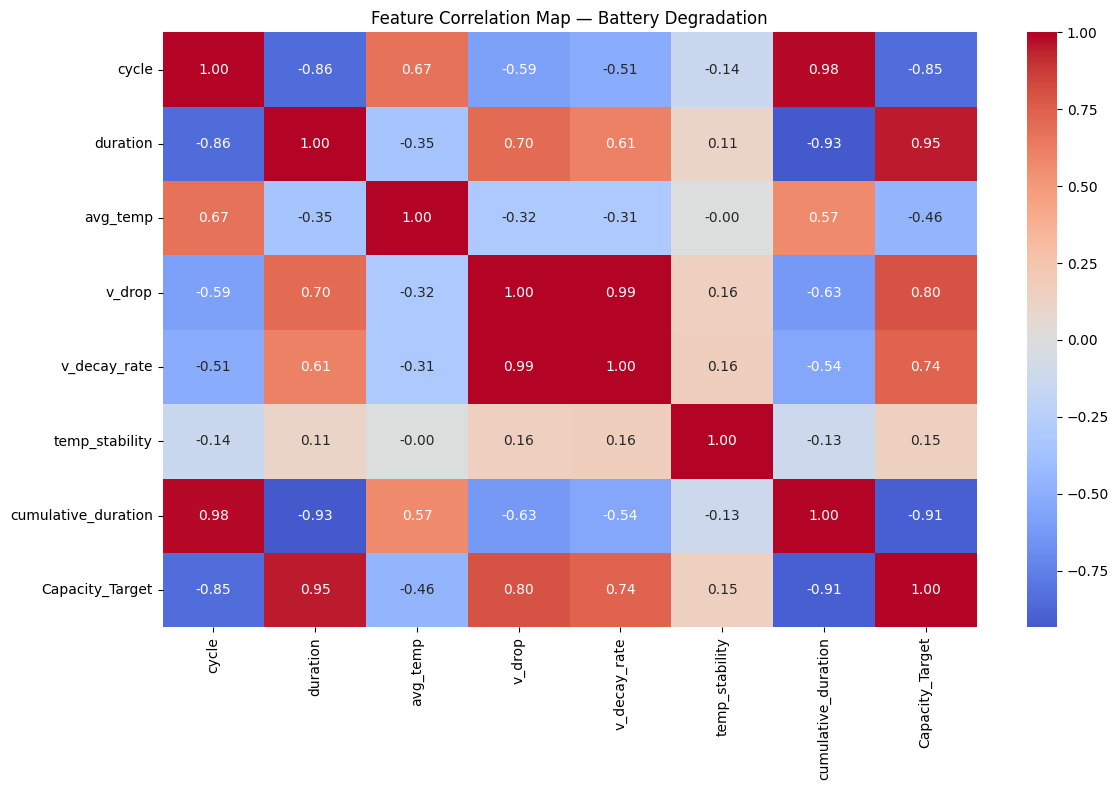

In [59]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure X_train is a DataFrame and y_train is handled correctly
# If X_train is already a DataFrame, copy it. If it's a NumPy array, convert it.
if isinstance(X_train, np.ndarray):
    # Use the 'features' list from your config for column names
    corr_df = pd.DataFrame(X_train, columns=features)
else:
    corr_df = X_train.copy()

# 2. Add the target. Since y_train is a NumPy array, just assign it directly.
corr_df['Capacity_Target'] = y_train

# 3. Plot
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Map — Battery Degradation")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

---
## Predict Reasoning


/Users/salmon/work/final_project/poc_project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


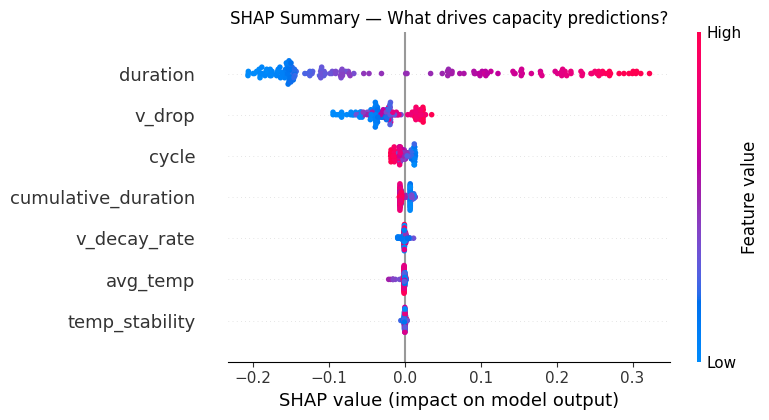

In [60]:
# ── B6: SHAP Setup ───────────────────────────────────────────────
# !pip install shap  # uncomment if needed
import shap

X_test_df = pd.DataFrame(X_test, columns=features)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_df)

# Global summary
plt.figure()
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Summary — What drives capacity predictions?")
plt.tight_layout()
plt.savefig("multicycle_shap_summary.png", dpi=150)
plt.show()


  Case     : Early Cycle (Fresh Battery)
  Cycle #  : 2
  Predicted Capacity : 1.8778 Ahr
  Actual Capacity    : 1.8565 Ahr
  Absolute Error     : 0.0213 Ahr


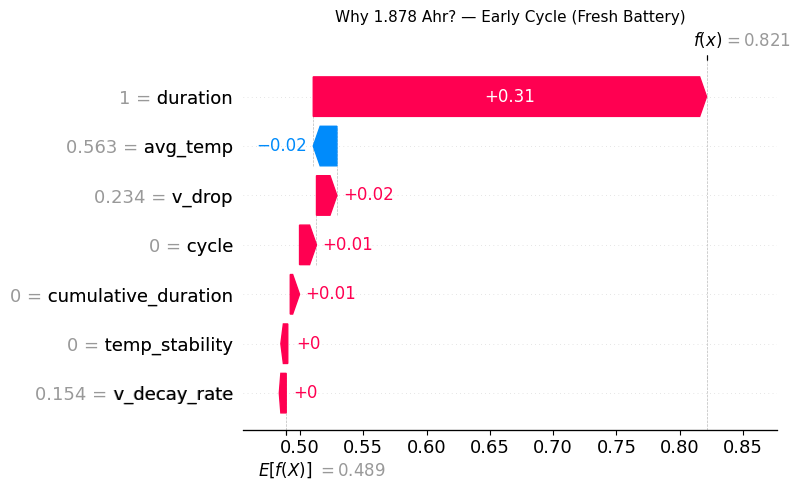


  🔋 Plain-Language Explanation:
     The model predicts this battery has 1.878 Ahr remaining capacity.
     1. 'duration' = 1.0000 → increases the predicted capacity by 0.3108 Ahr
     2. 'avg_temp' = 0.5628 → decreases the predicted capacity by 0.0187 Ahr
     3. 'v_drop' = 0.2344 → increases the predicted capacity by 0.0161 Ahr
     Battery Health Status: ✅ Healthy (93.9% of nominal)

  Case     : Mid-Life (Moderate Degradation)
  Cycle #  : 294
  Predicted Capacity : 1.4735 Ahr
  Actual Capacity    : 1.5382 Ahr
  Absolute Error     : 0.0647 Ahr


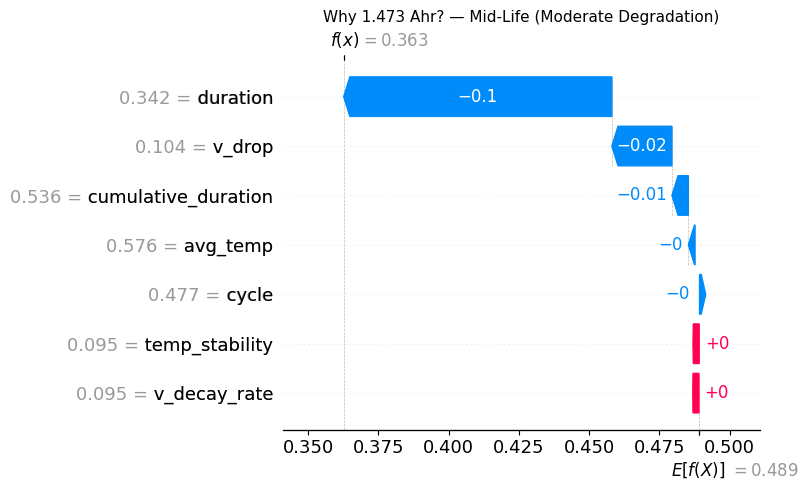


  🔋 Plain-Language Explanation:
     The model predicts this battery has 1.473 Ahr remaining capacity.
     1. 'duration' = 0.3424 → decreases the predicted capacity by 0.0954 Ahr
     2. 'v_drop' = 0.1041 → decreases the predicted capacity by 0.0214 Ahr
     3. 'cumulative_duration' = 0.5359 → decreases the predicted capacity by 0.0058 Ahr
     Battery Health Status: ⚠️ Degrading (73.7% of nominal)

  Case     : Near End-of-Life
  Cycle #  : 614
  Predicted Capacity : 1.3832 Ahr
  Actual Capacity    : 1.3251 Ahr
  Absolute Error     : 0.0582 Ahr


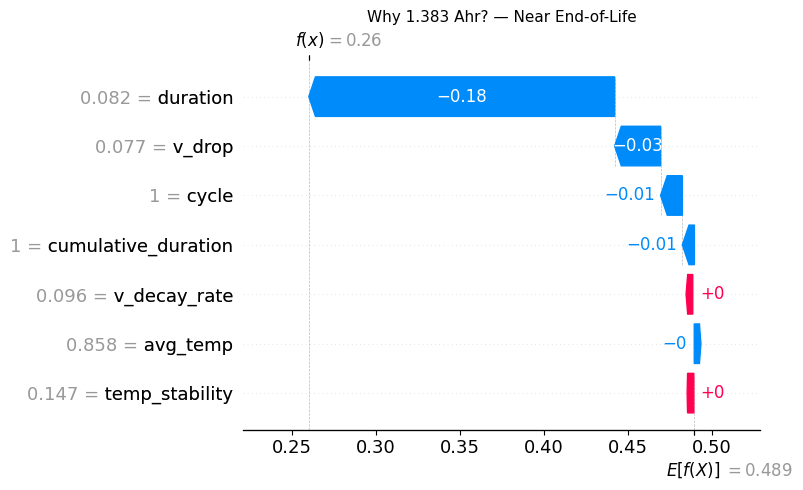


  🔋 Plain-Language Explanation:
     The model predicts this battery has 1.383 Ahr remaining capacity.
     1. 'duration' = 0.0819 → decreases the predicted capacity by 0.1817 Ahr
     2. 'v_drop' = 0.0769 → decreases the predicted capacity by 0.0273 Ahr
     3. 'cycle' = 1.0000 → decreases the predicted capacity by 0.0129 Ahr
     Battery Health Status: ❌ Near End-of-Life (69.2% of nominal)


In [61]:
# ── B6: Individual Reasoning for 3 Test Cases ────────────────────
test_cycle_nums = test_df['cycle'].values

# Pick early, mid, end-of-life cycles
case_indices = [0, len(X_test_df)//2, len(X_test_df)-1]
case_labels  = [
    "Early Cycle (Fresh Battery)",
    "Mid-Life (Moderate Degradation)",
    "Near End-of-Life"
]

for idx, label in zip(case_indices, case_labels):
    sample     = X_test_df.iloc[[idx]]
    pred       = scaler_y.inverse_transform(
                    xgb_model.predict(sample).reshape(-1,1))[0][0]
    actual     = test_df['capacity'].values[idx]
    cycle_num  = test_cycle_nums[idx]

    print(f"\n{'='*65}")
    print(f"  Case     : {label}")
    print(f"  Cycle #  : {cycle_num}")
    print(f"  Predicted Capacity : {pred:.4f} Ahr")
    print(f"  Actual Capacity    : {actual:.4f} Ahr")
    print(f"  Absolute Error     : {abs(pred-actual):.4f} Ahr")

    # SHAP waterfall for this case
    shap_single = explainer(sample)
    plt.figure(figsize=(9, 4))
    shap.plots.waterfall(shap_single[0], show=False)
    plt.title(f"Why {pred:.3f} Ahr? — {label}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"multicycle_shap_case_{idx}.png", dpi=150)
    plt.show()

    # Plain-language explanation for non-technical users
    sv   = shap_values.values[idx]
    top3 = np.argsort(np.abs(sv))[::-1][:3]
    print(f"\n  🔋 Plain-Language Explanation:")
    print(f"     The model predicts this battery has {pred:.3f} Ahr remaining capacity.")
    for rank, fi in enumerate(top3, 1):
        direction = "increases" if sv[fi] > 0 else "decreases"
        print(f"     {rank}. '{features[fi]}' = {sample[features[fi]].values[0]:.4f} "
              f"→ {direction} the predicted capacity by {abs(sv[fi]):.4f} Ahr")
    health_pct = (pred / 2.0) * 100  # 2.0 Ahr = nominal capacity
    status = "✅ Healthy" if pred > 1.6 else ("⚠️ Degrading" if pred > 1.4 else "❌ Near End-of-Life")
    print(f"     Battery Health Status: {status} ({health_pct:.1f}% of nominal)")

---
## Save models & scalers for pipeline

In [ ]:
import os, json, joblib

MULTI_SAVE_DIR = './saved_models/multi_cycle'
os.makedirs(MULTI_SAVE_DIR, exist_ok=True)

lstm_model.save(os.path.join(MULTI_SAVE_DIR, 'lstm_model.keras'))
joblib.dump(lr_model,   os.path.join(MULTI_SAVE_DIR, 'lr_model.pkl'))
joblib.dump(xgb_model,  os.path.join(MULTI_SAVE_DIR, 'xgb_model.pkl'))
joblib.dump(scaler_X,   os.path.join(MULTI_SAVE_DIR, 'scaler_X.pkl'))
joblib.dump(scaler_y,   os.path.join(MULTI_SAVE_DIR, 'scaler_y.pkl'))

config = {'features': features, 'window_size': WINDOW_SIZE}
with open(os.path.join(MULTI_SAVE_DIR, 'config.json'), 'w') as f:
    json.dump(config, f)
print('Multi-cycle artifacts saved.')




Multi-cycle artifacts saved.
